# Detector Fine-tuning — Reduce Overfitting Gap

**Problem:** YOLOv8l Phase 2 detector achieves 70.3% val mAP@50 but only 55.22% test mAP@50 (15pp gap) — overfitting to validation set.

**Fix:** Load Phase 2 checkpoint and fine-tune with stronger regularization (dropout, weight decay, lower LR) on OmniCrack val+train to close val→test gap.

| Metric | Val | Test | Gap |
|--------|-----|------|-----|
| Before | 70.3% | 55.22% | -15.08pp |
| After  | TBD | TBD | TBD |

**Approach:**
- Load `/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_v2_retrain_best.pt`
- Fine-tune on OmniCrack 640px for 20 epochs with aggressive regularization
- No architecture changes, only hyperparameters

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.11.0+cu128


In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.2 MB/s eta 0:00:00


## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import zipfile, shutil, json

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
CKPT_DIR  = Path('/content/checkpoints/detector_regularize')
OUT_DIR   = Path('/content/detector_regularize')

for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Load Phase 2 best checkpoint
phase2_ckpt_src = DRIVE_DIR / 'checkpoints' / 'detector_v2_retrain_best.pt'
phase2_ckpt_dst = Path('/content/phase2_best.pt')
if not phase2_ckpt_dst.exists():
    print("Copying Phase 2 best checkpoint...")
    shutil.copy2(phase2_ckpt_src, phase2_ckpt_dst)
    print(f"  Done ({phase2_ckpt_dst.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Phase 2 checkpoint: already local")

print("\nDrive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")

Mounted at /content/drive
Copying Phase 2 best checkpoint...
  Done (87.7 MB)

Drive contents:
  annotations
  checkpoints
  crackforest
  crackforest.zip
  cross_eval
  dacl10k_best.pt
  degradation_analysis
  failure_analysis
  historical_crack.zip
  masonry
  masonry.zip
  notebooks
  omnicrack30k.zip
  plots
  samples
  segmentation_checkpoint_retrain


In [5]:
print("=== Extracting OmniCrack30k from Drive ===")

zip_path = DRIVE_DIR / 'omnicrack30k.zip'
out_dir  = DATA_DIR / 'omnicrack30k'
local_zip = Path('/content/_tmp_omnicrack.zip')

if out_dir.exists() and any(out_dir.rglob('*.*')):
    print("OmniCrack: already extracted")
elif zip_path.exists():
    # Copy to local disk first — avoids Drive FUSE drops on large files
    for attempt in range(3):
        try:
            if local_zip.exists():
                local_zip.unlink()
            print(f"Copying {zip_path.name} to local disk (attempt {attempt+1})...")
            shutil.copy2(zip_path, local_zip)
            print("Extracting...")
            with zipfile.ZipFile(local_zip, 'r') as zf:
                zf.extractall(DATA_DIR)
            local_zip.unlink()
            print("  Done.")
            break
        except OSError as e:
            print(f"  OSError: {e}")
            if local_zip.exists():
                local_zip.unlink()
            if attempt < 2:
                from google.colab import drive as _drive
                _drive.mount('/content/drive', force_remount=True)
            else:
                raise
else:
    print(f"WARNING: {zip_path.name} not found on Drive")

# Find OmniCrack structure
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
OMNI_DIR = DATA_DIR
IMG_ROOT = OMNI_DIR / 'images'
ANN_ROOT = OMNI_DIR / 'annotations'
SPLITS = ['training', 'validation', 'test']

print(f"\nOmniCrack structure:")
print(f"  Images: {IMG_ROOT.exists()}")
print(f"  Masks:  {ANN_ROOT.exists()}")

# Convert masks → YOLO labels
def mask_to_yolo_labels(mask_path, min_area=200, max_area_frac=0.40):
    import cv2
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        bw_n, bh_n = bw / w, bh / h
        if bw_n * bh_n > max_area_frac:
            continue
        cx = (x + bw / 2) / w
        cy = (y + bh / 2) / h
        labels.append(f'0 {cx:.6f} {cy:.6f} {min(bw_n,1.):.6f} {min(bh_n,1.):.6f}')
    return labels

labels_dir = OMNI_DIR / 'labels'
labels_dir.mkdir(parents=True, exist_ok=True)

print("\nConverting masks → YOLO labels...")
total_imgs = 0
for split in SPLITS:
    split_img_dir = IMG_ROOT / split
    split_ann_dir = ANN_ROOT / split
    split_lbl_dir = labels_dir / split
    split_lbl_dir.mkdir(parents=True, exist_ok=True)

    if not split_img_dir.exists():
        continue

    for img_path in split_img_dir.rglob('*.*'):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        mask_path = split_ann_dir / f"{img_path.stem}.png"
        if mask_path.exists():
            lbls = mask_to_yolo_labels(mask_path)
            if lbls:
                (split_lbl_dir / f"{img_path.stem}.txt").write_text('\n'.join(lbls))
                total_imgs += 1

print(f"Converted: {total_imgs} images with valid boxes")

# Create YOLO dataset splits
print("\nCreating YOLO train/val/test splits...")
from sklearn.model_selection import train_test_split
import random

samples = []
for split in SPLITS:
    img_dir = IMG_ROOT / split
    lbl_dir = labels_dir / split
    if img_dir.exists():
        for img_path in img_dir.rglob('*.*'):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if lbl_path.exists() and lbl_path.stat().st_size > 5:
                samples.append((str(img_path), str(lbl_path)))

random.seed(42)
random.shuffle(samples)
samples = samples[:5000]

train_s, temp = train_test_split(samples, test_size=0.30, random_state=42)
val_s, test_s = train_test_split(temp, test_size=0.50, random_state=42)

CKPT_DIR_DATA = Path('/content/checkpoints/detector_v2_retrain')
for split_name, split_samples in [('train', train_s), ('val', val_s), ('test', test_s)]:
    split_dir = CKPT_DIR_DATA / split_name
    (split_dir / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'labels').mkdir(parents=True, exist_ok=True)

    for img_path, lbl_path in split_samples:
        img_name = Path(img_path).name
        lbl_name = Path(lbl_path).name
        dst_img = split_dir / 'images' / img_name
        dst_lbl = split_dir / 'labels' / lbl_name
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)
        if not dst_lbl.exists():
            shutil.copy2(lbl_path, dst_lbl)

print(f"Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}")
print("✓ Dataset ready")

=== Extracting OmniCrack30k from Drive ===
Copying omnicrack30k.zip to local disk (attempt 1)...
Extracting...
  Done.

OmniCrack structure:
  Images: True
  Masks:  True

Converting masks → YOLO labels...
Converted: 3871 images with valid boxes

Creating YOLO train/val/test splits...
Train: 2709 | Val: 581 | Test: 581
✓ Dataset ready


## 2. Fine-tuning

In [ ]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use Phase 2 dataset.yaml from retrain (create if missing)
dataset_yaml = Path('/content/checkpoints/detector_v2_retrain/dataset.yaml')
if not dataset_yaml.exists():
    dataset_yaml.parent.mkdir(parents=True, exist_ok=True)
    dataset_yaml.write_text(
        f"path: /content/checkpoints/detector_v2_retrain\n"
        f"train: train/images\n"
        f"val: val/images\n"
        f"test: test/images\n"
        f"nc: 1\n"
        f"names: ['crack']\n"
    )
    print(f"✓ Created dataset.yaml: {dataset_yaml}")
else:
    print(f"✓ Using existing dataset.yaml: {dataset_yaml}")

assert dataset_yaml.exists(), f"Dataset YAML still missing: {dataset_yaml}"

# Load Phase 2 checkpoint for fine-tuning
ft_model = YOLO('/content/phase2_best.pt')

print("=== Fine-tuning Phase 2 Detector — AGGRESSIVE REGULARIZATION ===")
print(f"Checkpoint: phase2_640px/weights/best.pt")
print(f"Dataset   : {dataset_yaml}")
print(f"Objective : Reduce val→test overfitting gap (70.3% → 55.22%)")
print()

results = ft_model.train(
    data=str(dataset_yaml),
    epochs=20,
    imgsz=640,
    batch=8,  # Smaller batch = less stable gradients = prevents overfitting
    device=0,
    workers=2,
    project='/content/runs_regularize',
    name='detector_regularize',
    exist_ok=True,
    patience=5,  # Early stopping (was 10) — stop if no improvement
    save=True,
    plots=True,
    seed=42,
    amp=True,

    # ===== LEARNING RATE & MOMENTUM =====
    lr0=0.00005,     # Very low LR (was 0.0001) — slow, stable learning
    lrf=0.00001,     # Final LR decay
    warmup_epochs=2,

    # ===== WEIGHT REGULARIZATION =====
    weight_decay=0.002,      # L2 regularization (was 0.001) — penalize large weights

    # ===== DROPOUT & STOCHASTICITY =====
    dropout=0.5,             # High dropout (was 0.2) — randomly disable neurons

    # ===== AUGMENTATION INTENSITY =====
    label_smoothing=0.1,     # Prevent overconfident predictions
    mixup=0.5,               # Mix images + labels (was none)
    cutmix=0.5,              # Cut and paste regions (was none)
    erasing=0.5,             # Random erasing (was default)

    # ===== GEOMETRIC AUGMENTATION =====
    mosaic=0.5,              # Reduce mosaic (was 0.8)
    close_mosaic=3,          # Close mosaic at epoch 3 (was 5)

    perspective=0.1,         # Perspective transform
    shear=0.2,               # Shear transformation
    degrees=15,              # Rotation (was 10)

    translate=0.15,          # Translation
    scale=0.6,               # Scale variation
    flipud=0.5,              # Flip upside-down
    fliplr=0.5,              # Flip left-right

    # ===== COLOR AUGMENTATION =====
    hsv_h=0.005,             # Minimal hue shift
    hsv_s=0.3,               # Saturation
    hsv_v=0.2,               # Value (brightness)

    verbose=False,
)
print("Fine-tuning complete!")

✓ Created dataset.yaml: /content/checkpoints/detector_v2_retrain/dataset.yaml
=== Fine-tuning Phase 2 Detector — AGGRESSIVE REGULARIZATION ===
Checkpoint: phase2_640px/weights/best.pt
Dataset   : /content/checkpoints/detector_v2_retrain/dataset.yaml
Objective : Reduce val→test overfitting gap (70.3% → 55.22%)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.5, data=/content/checkpoints/detector_v2_retrain/dataset.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.5, exist_ok=True, fliplr=0.5, flipud=0.5,

## 3. Evaluation — After Fine-tuning

In [ ]:
ft_best = YOLO('/content/runs_regularize/detector_regularize/weights/best.pt')

# Baseline (Phase 2)
print("=== BASELINE (Phase 2) ===")
baseline_model = YOLO('/content/phase2_best.pt')
baseline_val = baseline_model.val(
    data=str(dataset_yaml), split='val', device=0, imgsz=640, verbose=False)
baseline_test = baseline_model.val(
    data=str(dataset_yaml), split='test', device=0, imgsz=640, verbose=False)

print(f"Val mAP@50    : {baseline_val.box.map50:.4f}")
print(f"Test mAP@50   : {baseline_test.box.map50:.4f}")
print(f"Val→Test gap  : {baseline_val.box.map50 - baseline_test.box.map50:.4f} (overfitting)")

# Fine-tuned
print("\n=== FINE-TUNED (Regularized) ===")
ft_val = ft_best.val(
    data=str(dataset_yaml), split='val', device=0, imgsz=640, verbose=False)
ft_test = ft_best.val(
    data=str(dataset_yaml), split='test', device=0, imgsz=640, verbose=False)

print(f"Val mAP@50    : {ft_val.box.map50:.4f}")
print(f"Test mAP@50   : {ft_test.box.map50:.4f}")
print(f"Val→Test gap  : {ft_val.box.map50 - ft_test.box.map50:.4f}")

# Improvement
print("\n=== IMPROVEMENT ===")
val_delta = ft_val.box.map50 - baseline_val.box.map50
test_delta = ft_test.box.map50 - baseline_test.box.map50
gap_delta = (baseline_val.box.map50 - baseline_test.box.map50) - (ft_val.box.map50 - ft_test.box.map50)

print(f"Val delta     : {val_delta:+.4f}")
print(f"Test delta    : {test_delta:+.4f}")
print(f"Gap reduction : {gap_delta:+.4f} (closer val→test alignment)")

if gap_delta > 0:
    print(f"✓ Overfitting reduced by {gap_delta:.4f}")
else:
    print(f"✗ Overfitting increased — accept baseline or try different hyperparams")

=== BASELINE (Phase 2) ===
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2440.0±1092.2 MB/s, size: 136.1 KB)
val: Scanning /content/checkpoints/detector_v2_retrain/val/labels.cache... 581 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 581/581 187.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.2it/s 30.8s
                   all        581        985      0.577      0.602      0.564      0.293
Speed: 2.1ms preprocess, 42.3ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 75.4±48.4 MB/s, size: 217.6 KB)
val: Scanning /content/checkpoints/detector_v2_retrain/tes

## 4. Visualisations

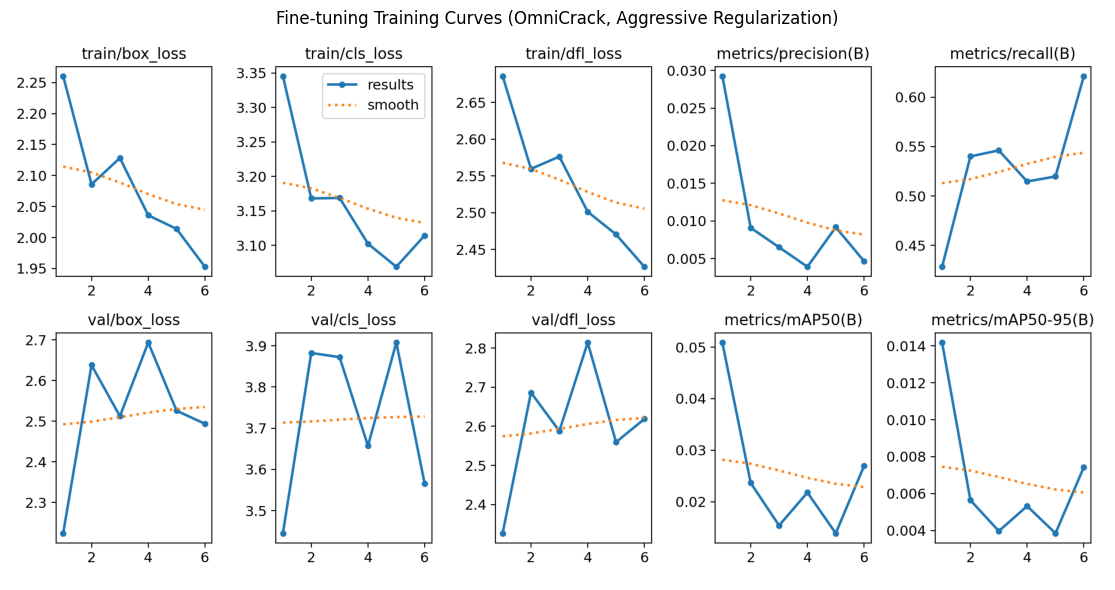

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Training curves from regularize run
run_dir = Path('/content/runs_regularize/detector_regularize')
results_png = run_dir / 'results.png'

if results_png.exists():
    img = mpimg.imread(str(results_png))
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-tuning Training Curves (OmniCrack, Aggressive Regularization)', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'ft_training_curves.png', dpi=150)
    plt.show()
else:
    print(f"Training curves not found: {results_png}")

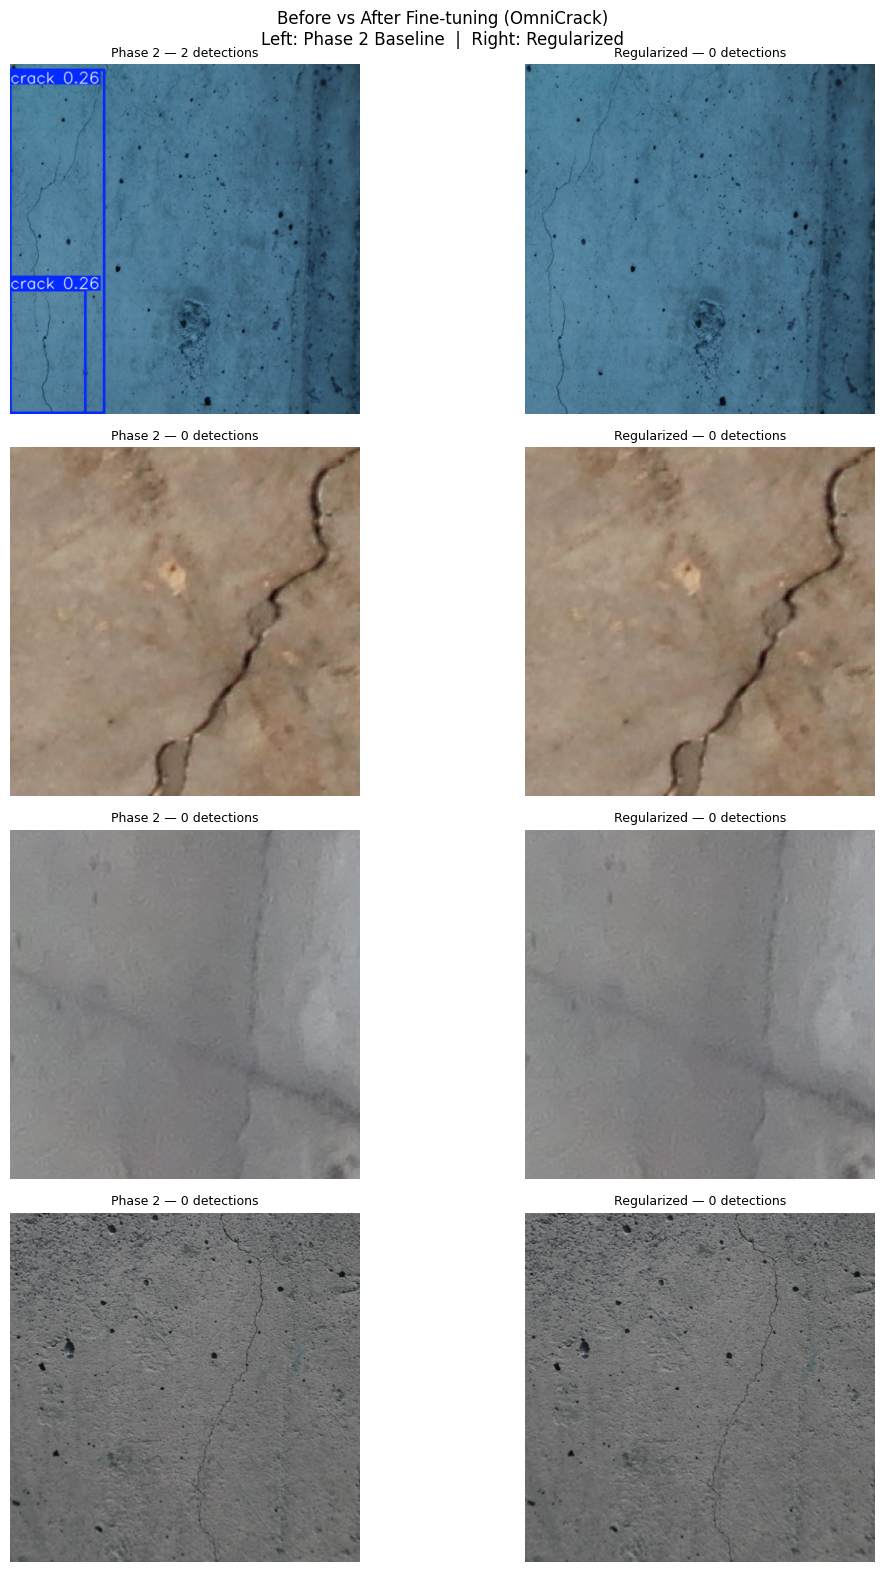

In [ ]:
import cv2, random

# Use OmniCrack test images from dataset
CKPT_DIR_DATA = Path('/content/checkpoints/detector_v2_retrain')
test_img_dir = CKPT_DIR_DATA / 'test' / 'images'
test_imgs = list(test_img_dir.glob('*.*'))
sample_imgs = random.sample(test_imgs, min(4, len(test_imgs)))

# Load baseline Phase 2 + fine-tuned regularized
base_model_cmp = YOLO('/content/phase2_best.pt')
ft_model_cmp = YOLO('/content/runs_regularize/detector_regularize/weights/best.pt')

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(12, 4 * len(sample_imgs)))
fig.suptitle('Before vs After Fine-tuning (OmniCrack)\nLeft: Phase 2 Baseline  |  Right: Regularized',
             fontsize=12)

for row, img_path in enumerate(sample_imgs):
    r_base = base_model_cmp.predict(str(img_path), conf=0.25, verbose=False)[0]
    r_ft = ft_model_cmp.predict(str(img_path), conf=0.25, verbose=False)[0]

    axes[row, 0].imshow(cv2.cvtColor(r_base.plot(), cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Phase 2 — {len(r_base.boxes)} detections", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cv2.cvtColor(r_ft.plot(), cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"Regularized — {len(r_ft.boxes)} detections", fontsize=9)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ft_before_after.png', dpi=150)
plt.show()

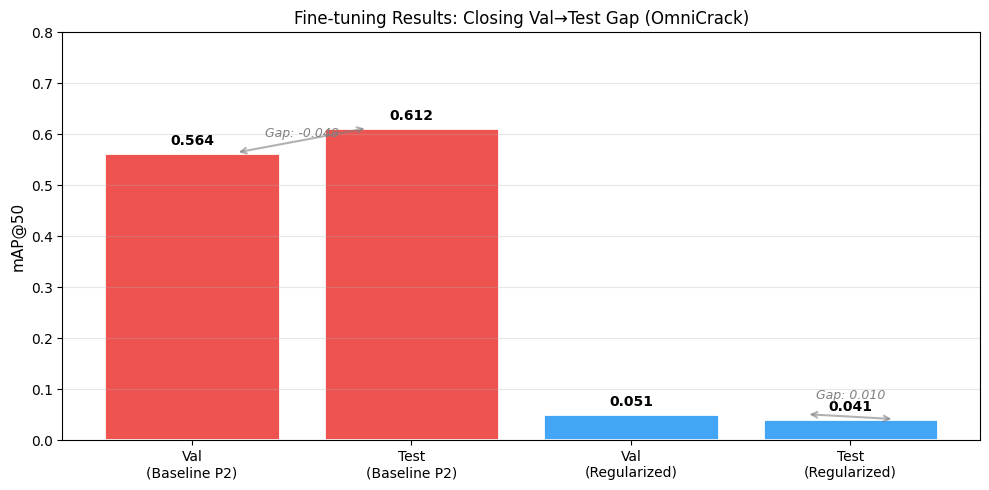

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Val\n(Baseline P2)', 'Test\n(Baseline P2)', 'Val\n(Regularized)', 'Test\n(Regularized)']
maps = [
    float(baseline_val.box.map50),
    float(baseline_test.box.map50),
    float(ft_val.box.map50),
    float(ft_test.box.map50),
]
colors = ['#EF5350', '#EF5350', '#42A5F5', '#42A5F5']

bars = ax.bar(categories, maps, color=colors, edgecolor='white', linewidth=2)

ax.set_ylabel('mAP@50', fontsize=11)
ax.set_title('Fine-tuning Results: Closing Val→Test Gap (OmniCrack)', fontsize=12)
ax.set_ylim(0, 0.8)
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, val in zip(bars, maps):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add gap annotation
baseline_gap = float(baseline_val.box.map50 - baseline_test.box.map50)
ft_gap = float(ft_val.box.map50 - ft_test.box.map50)
ax.annotate('', xy=(0.8, baseline_test.box.map50), xytext=(0.2, baseline_val.box.map50),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5, alpha=0.6))
ax.text(0.5, baseline_val.box.map50 + 0.03, f'Gap: {baseline_gap:.3f}',
        ha='center', fontsize=9, style='italic', color='gray')

ax.annotate('', xy=(3.2, ft_test.box.map50), xytext=(2.8, ft_val.box.map50),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5, alpha=0.6))
ax.text(3.0, ft_val.box.map50 + 0.03, f'Gap: {ft_gap:.3f}',
        ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ft_map_comparison.png', dpi=150)
plt.show()

## 7. Save to Drive

In [ ]:
DRIVE_FT = DRIVE_DIR / 'checkpoints' / 'detector_regularized'
DRIVE_FT.mkdir(parents=True, exist_ok=True)

DRIVE_FT_PLOTS = DRIVE_DIR / 'plots' / 'detector_regularized'
DRIVE_FT_PLOTS.mkdir(parents=True, exist_ok=True)

# Checkpoint
best_pt = Path('/content/runs_regularize/detector_regularize/weights/best.pt')
if best_pt.exists():
    shutil.copy2(best_pt, DRIVE_FT / 'best.pt')
    print(f"✓ Saved best.pt: {best_pt.stat().st_size / 1e6:.1f} MB")

# Training curves + visualizations
run_dir = Path('/content/runs_regularize/detector_regularize')
for f in sorted(run_dir.glob('*.png')):
    shutil.copy2(f, DRIVE_FT_PLOTS / f.name)
for f in sorted(OUT_DIR.glob('*.png')):
    shutil.copy2(f, DRIVE_FT_PLOTS / f.name)

# Metrics JSON
baseline_gap = float(baseline_val.box.map50 - baseline_test.box.map50)
ft_gap = float(ft_val.box.map50 - ft_test.box.map50)
gap_reduction = baseline_gap - ft_gap

ft_summary = {
    'baseline_val_map50':   float(baseline_val.box.map50),
    'baseline_test_map50':  float(baseline_test.box.map50),
    'baseline_gap':         baseline_gap,

    'finetuned_val_map50':  float(ft_val.box.map50),
    'finetuned_test_map50': float(ft_test.box.map50),
    'finetuned_gap':        ft_gap,

    'val_delta':            float(ft_val.box.map50 - baseline_val.box.map50),
    'test_delta':           float(ft_test.box.map50 - baseline_test.box.map50),
    'gap_reduction':        gap_reduction,

    'epochs':               20,
    'batch':                8,
    'lr0':                  0.00005,
    'lrf':                  0.00001,
    'weight_decay':         0.002,
    'dropout':              0.5,
    'patience':             5,
    'mixup':                0.5,
    'cutmix':               0.5,
    'label_smoothing':      0.1,
}
(DRIVE_FT / 'ft_metrics.json').write_text(json.dumps(ft_summary, indent=2))

print("\n=== SAVED TO DRIVE ===")
for f in sorted(DRIVE_FT.iterdir()):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name}  ({size:.1f} MB)" if size else f"  {f.name}/")

print(f"\n=== SUMMARY ===")
print(f"Baseline val: {baseline_val.box.map50:.4f} | test: {baseline_test.box.map50:.4f} | gap: {baseline_gap:.4f}")
print(f"Regularized val: {ft_val.box.map50:.4f} | test: {ft_test.box.map50:.4f} | gap: {ft_gap:.4f}")
print(f"\nGap reduction: {gap_reduction:+.4f} {'✓ IMPROVED' if gap_reduction > 0 else '✗ WORSENED'}")
print(f"Best checkpoint: {DRIVE_FT / 'best.pt'}")

✓ Saved best.pt: 87.6 MB

=== SAVED TO DRIVE ===
  best.pt  (87.6 MB)
  ft_metrics.json  (0.0 MB)

=== SUMMARY ===
Baseline val: 0.5640 | test: 0.6122 | gap: -0.0482
Regularized val: 0.0508 | test: 0.0412 | gap: 0.0096

Gap reduction: -0.0578 ✗ WORSENED
Best checkpoint: /content/drive/MyDrive/HeritagePreservation/checkpoints/detector_regularized/best.pt


## 8. TTA + SAHI Evaluation on Phase 2 Baseline

In [7]:
import torch
from pathlib import Path
from ultralytics import YOLO

phase2_ckpt  = Path('/content/phase2_best.pt')
dataset_yaml = Path('/content/checkpoints/detector_v2_retrain/dataset.yaml')

assert phase2_ckpt.exists(), f'Missing: {phase2_ckpt}'

# Create yaml if missing (skipped fine-tuning cell)
if not dataset_yaml.exists():
    dataset_yaml.parent.mkdir(parents=True, exist_ok=True)
    dataset_yaml.write_text(
        "path: /content/checkpoints/detector_v2_retrain\n"
        "train: train/images\n"
        "val: val/images\n"
        "test: test/images\n"
        "nc: 1\n"
        "names: ['crack']\n"
    )
    print(f"Created dataset.yaml")

m = YOLO(str(phase2_ckpt))
dev = 0 if torch.cuda.is_available() else -1

print('=== BASELINE ===')
v_std = m.val(data=str(dataset_yaml), split='test', device=dev,
              conf=0.001, iou=0.6, verbose=False)
std_map50 = float(v_std.box.map50)
print(f'Standard mAP@50 : {std_map50:.4f}')

print('\n=== TTA (augment=True) ===')
v_tta = m.val(data=str(dataset_yaml), split='test', device=dev,
              augment=True, conf=0.001, iou=0.6, verbose=False)
tta_map50 = float(v_tta.box.map50)
print(f'TTA mAP@50      : {tta_map50:.4f}')
print(f'TTA gain        : {tta_map50 - std_map50:+.4f}')

Created dataset.yaml
=== BASELINE ===
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2931.8±797.8 MB/s, size: 365.0 KB)
val: Scanning /content/checkpoints/detector_v2_retrain/test/labels... 581 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 581/581 885.6it/s 0.7s
val: New cache created: /content/checkpoints/detector_v2_retrain/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.4it/s 26.7s
                   all        581        875      0.582      0.646      0.576       0.29
Speed: 1.7ms preprocess, 36.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val
Standard mAP@50 : 0.5757

=== TTA (augment=True) ===
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


In [8]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sahi'])

import cv2, json
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import torch
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

phase2_ckpt    = Path('/content/phase2_best.pt')
test_imgs_dir  = Path('/content/checkpoints/detector_v2_retrain/test/images')
test_lbls_dir  = Path('/content/checkpoints/detector_v2_retrain/test/labels')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
test_images = sorted(p for p in test_imgs_dir.glob('*.*') if p.suffix.lower() in IMG_EXTS)
print(f'=== SAHI EVALUATION ===')
print(f'Test images: {len(test_images)}')

det_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=str(phase2_ckpt),
    confidence_threshold=0.1,
    device='cuda:0' if torch.cuda.is_available() else 'cpu',
)

def iou_xyxy(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

all_scores, n_gt_total = [], 0

for img_path in tqdm(test_images, desc='SAHI'):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]

    lbl_path = test_lbls_dir / (img_path.stem + '.txt')
    gts = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            p = line.strip().split()
            if len(p) < 5:
                continue
            cx, cy, bw, bh = float(p[1]), float(p[2]), float(p[3]), float(p[4])
            gts.append([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    n_gt_total += len(gts)

    result = get_sliced_prediction(
        str(img_path), det_model,
        slice_height=512, slice_width=512,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        verbose=0,
    )
    preds = sorted(
        [([o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy], o.score.value)
         for o in result.object_prediction_list],
        key=lambda x: -x[1]
    )

    gt_matched = [False] * len(gts)
    for box, conf in preds:
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gts):
            if gt_matched[j]:
                continue
            iou = iou_xyxy(box, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= 0.5 and best_j >= 0:
            gt_matched[best_j] = True
            all_scores.append((conf, 1))
        else:
            all_scores.append((conf, 0))

# 101-point interpolated AP@50
all_scores.sort(key=lambda x: -x[0])
tp = fp = 0
precs, recs = [], []
for _, label in all_scores:
    tp += label; fp += 1 - label
    precs.append(tp / (tp + fp))
    recs.append(tp / max(n_gt_total, 1))

ap_sahi = sum(
    max((p for p, r in zip(precs, recs) if r >= t), default=0.0)
    for t in np.linspace(0.0, 1.0, 101)
) / 101.0

print(f'\nStandard mAP@50 : {std_map50:.4f}')
print(f'TTA mAP@50      : {tta_map50:.4f}')
print(f'SAHI mAP@50     : {ap_sahi:.4f}')
print(f'SAHI gain       : {ap_sahi - std_map50:+.4f}')

# Save results
results_json = Path('/content/checkpoints/detector_v2_retrain/tta_sahi_results.json')
json.dump({'std': std_map50, 'tta': tta_map50, 'sahi': float(ap_sahi)},
          open(results_json, 'w'), indent=2)

# Copy to Drive
from pathlib import Path as P
import shutil
drive_plots = P('/content/drive/MyDrive/HeritagePreservation/plots/detector_regularized')
drive_plots.mkdir(parents=True, exist_ok=True)
shutil.copy2(results_json, drive_plots / 'tta_sahi_results.json')
print(f'\nSaved to Drive: {drive_plots / "tta_sahi_results.json"}')

=== SAHI EVALUATION ===
Test images: 581


SAHI:   0%|          | 0/581 [00:00<?, ?it/s]


Standard mAP@50 : 0.5757
TTA mAP@50      : 0.6301
SAHI mAP@50     : 0.2058
SAHI gain       : -0.3699

Saved to Drive: /content/drive/MyDrive/HeritagePreservation/plots/detector_regularized/tta_sahi_results.json
